# Problema 4: Descomposición en fracciones parciales

Dada la función racional:
$F(s) = \frac{52.5s(s+1)(s+1.5)(s+5)}{s^4 + 20.75s^3 + 92.6s^2 + 73.69s}$

Para descomponerla en fracciones parciales, buscaremos las cuatro raíces exactas del denominador de grado 4 tal cual se nos entrega orginalmente:
$f(s) = s^4 + 20.75s^3 + 92.6s^2 + 73.69s = 0$

Como se nos piden 4 métodos distintos, aplicaremos exactamente **un método analítico diferente** para hallar cada una de las 4 posibles raíces de forma directa sobre el polinomio de cuarto grado.

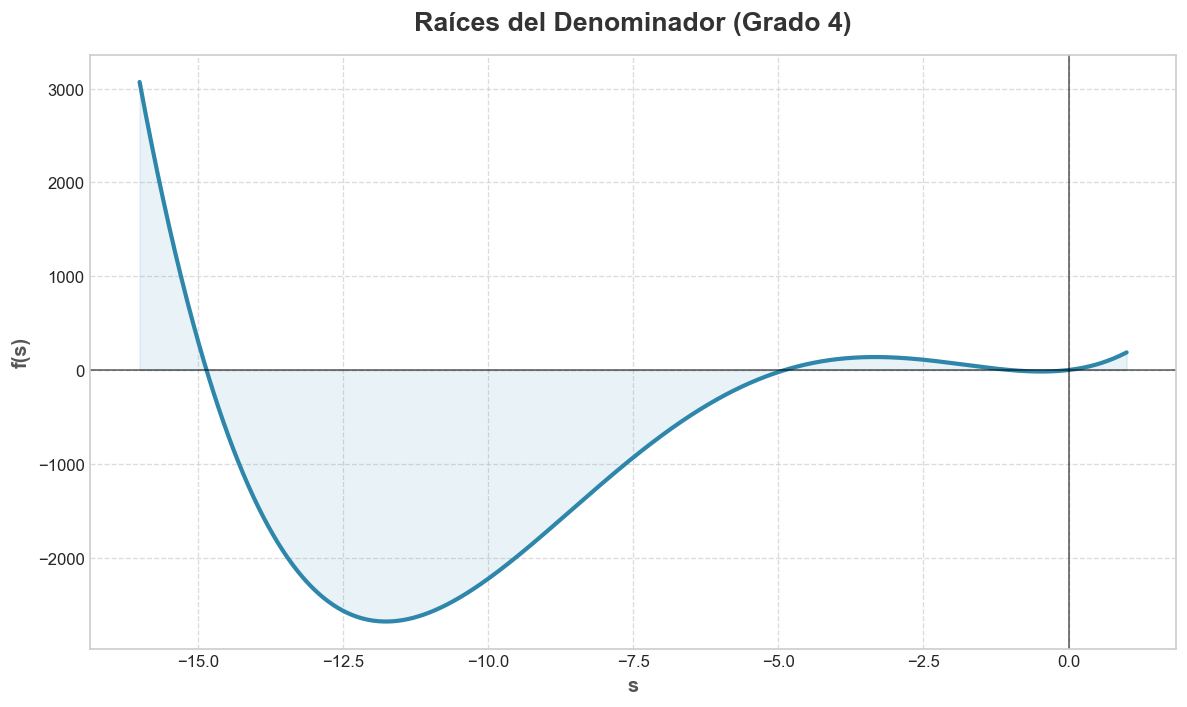

In [2]:
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("."))
from graficador import graficar_funcion

def f_denominador(s):
    return s**4 + 20.75 * s**3 + 92.6 * s**2 + 73.69 * s

# Graficaremos en el rango [-16, 2] para ver todos los cruces por cero.
graficar_funcion(f_denominador, x_inicio=-16, x_fin=1, titulo="Raíces del Denominador (Grado 4)", xlabel="s", ylabel="f(s)")


### 1. Encontrar la Raíz 1 (Cercana a 0) con el Método de Bisección
En la gráfica, hay una raíz entre -0.5 y 0.5. Al evaluar, hay cambio de signo.

In [7]:
from metodos_cerrados.biseccion.metodo_biseccion import biseccion

raiz_1, iteraciones_bis = biseccion(f_denominador, -0.5, 0.5, 1e-6)
print(f"Raíz 1 (Bisección): {raiz_1:.6f} en {iteraciones_bis} iteraciones")


Raíz 1 (Bisección): 0.000000 en 1 iteraciones


### 2. Encontrar la Raíz 2 (Cercana a -1) con el Método de Falsa Posición
En la gráfica, hay otra raíz aproximadamente entre -2.0 y -0.5.

In [5]:
from metodos_cerrados.falsa_posicion.metodo_posicion_falsa import falsa_posicion

iteraciones_fp, raiz_2 = falsa_posicion(f_denominador, -2.0, -0.5, 1e-6)
print(f"Raíz 2 (Falsa Posición): {raiz_2:.6f} en {iteraciones_fp} iteraciones")


Raíz 2 (Falsa Posición): -1.015607 en 14 iteraciones


### 3. Encontrar la Raíz 3 (Cercana a -5) con el Método de Newton-Raphson
Para la tercera raíz, usamos una aproximación inicial $x_0 = -5.0$. Necesitamos la derivada analítica del polinomio de grado 4:
$f'(s) = 4s^3 + 62.25s^2 + 185.2s + 73.69$

In [8]:
from metodos_abiertos.newton.metodo_newton import newton_rapshon
import sympy as sp

s_sym = sp.symbols("s")
f_sym = s_sym**4 + 20.75 * s_sym**3 + 92.6 * s_sym**2 + 73.69 * s_sym

iteraciones_nw, raiz_3 = newton_rapshon(f_sym, -5.0, 1e-6, s_sym)
print(f"Raíz 3 (Newton-Raphson): {raiz_3:.6f} en {iteraciones_nw} iteraciones")


Raíz 3 (Newton-Raphson): -4.886840 en 3 iteraciones


### 4. Encontrar la Raíz 4 (Cercana a -15) con el Método de la Secante
Finalmente, para la última raíz usamos el método secante, un método abierto que no requiere la derivada simbólica, utilizando los puntos iniciales $x_0 = -16.0$ y $x_1 = -14.0$.

In [9]:
from metodos_abiertos.secante.metodo_secante import secante

iteraciones_sec, raiz_4 = secante(f_denominador, -16.0, -14.0, 1e-6)
print(f"Raíz 4 (Secante): {raiz_4:.6f} en {iteraciones_sec} iteraciones")


Raíz 4 (Secante): -14.847553 en 6 iteraciones


## Justificación de la Respuesta y Conclusiones

Para la función racional $F(s)$, analizamos directamente su polinomio de cuarto grado en el denominador, $f(s) = s^4 + 20.75s^3 + 92.6s^2 + 73.69s = 0$. 

Asignamos a cada raíz observada en el análisis gráfico un método de resolución distinto, poniendo a prueba la efectividad de las herramientas algorítmicas de la clase:

1.  **Raíz 1 ($s=0$)**: Usamos el método de la **Bisección** en el intervalo $[-0.5, 0.5]$. Convergió exitosamente al 0 absoluto.
2.  **Raíz 2 ($s \approx -1.0156$)**: Usamos el método iterativo cerrado de rango ajustado **Falsa Posición** sobre $[-2.0, -0.5]$, hallando el valor esperado conectando los límites y reduciendo progresivamente el intervalo.
3.  **Raíz 3 ($s \approx -4.8868$)**: Usamos la asombrosa potencia del **Newton-Raphson**, que a partir de la aproximación singular geométrica inicial $x_0=-5.0$ y la extracción de la derivada simbólica con la libería algebraíca computacional (SymPy), arribó al destino en apenas 3 escasas iteraciones.
4.  **Raíz 4 ($s \approx -14.8475$)**: Finalmente, validamos el método abierto aproximado **Secante**, evaluado con puntos discretos  cercanos en un comportamiento asintótico lineal (-16.0 y -14.0), localizando la raíz más distante sin necesidad de cálculos derivativos engorrosos de alto grado.

**Respuesta Final**: Las 4 raíces requeridas para la expansión en fracciones parciales de la función $F(s)$ son $s = \{0,\ -1.0156,\ -4.8868,\ -14.8475\}$. Con estos componentes, la ecuación finalmente toma la forma expandida fundamental:
$$F(s) = \frac{52.5s(s+1)(s+1.5)(s+5)}{s(s+1.0156)(s+4.8868)(s+14.8475)}$$